# ✈️ Flight Delay Prediction
## EDA + Feature Engineering + Regression Model
---
**Dataset:** 2015 Flight Delays & Cancellations — Kaggle  
**Objetivo:** Estimar los minutos de retraso de llegada de un vuelo  
**Modelos:** Random Forest Regressor · XGBoost Regressor  

### 📥 Instrucciones para Google Colab + Drive
Este notebook esta preparado para trabajar directamente desde Google Drive.

Estructura esperada en Drive para los CSV:

`MyDrive/fligts/`

Dentro de esa carpeta deben estar:

- `flights.csv`
- `airlines.csv`
- `airports.csv`

El proyecto seguira usando esta carpeta para guardar el modelo empaquetado:

`MyDrive/flight-delay-prediction/models/flight_delay_model.joblib`

Si los CSV no existen, el notebook intentara descargarlos automaticamente desde Kaggle usando `kagglehub` y copiarlos a `MyDrive/fligts/`. Si Kaggle pide autenticacion, descarga manualmente el dataset desde https://www.kaggle.com/datasets/usdot/flight-delays y sube los tres CSV a `MyDrive/fligts/`.


## Guion de Presentacion - EDA y Modelo

### 1. Contexto del notebook

En este notebook estoy construyendo el modelo principal del proyecto. El objetivo ya no es clasificar vuelos como retrasados o no retrasados, sino estimar directamente los minutos de retraso de llegada. Por eso el problema es de regresion supervisada, no de clasificacion, y el modelo cumple con la restriccion de no ser una regresion simple.

### 2. Dataset y carga de datos

Aqui cargo el dataset de Kaggle de vuelos de Estados Unidos 2015. En esta corrida trabajamos con una muestra representativa de 498,464 registros, suficiente para hacer EDA, entrenar modelos y mantener Colab estable.

### 3. Revision inicial de calidad

En esta parte reviso tipos de datos, nulos y estructura general. Las columnas de causas de retraso tienen muchos nulos porque no todos los vuelos tienen una causa asignada. Para el modelo, esos nulos se interpretan como cero minutos en esa causa.

### 4. Distribucion de retrasos

Aqui se observa que aproximadamente 17.9% de los vuelos tuvieron mas de 15 minutos de retraso. Cuando un vuelo se retrasa, el retraso promedio es de 61 minutos, y el 80% de esos retrasos queda por debajo de 84 minutos. Esto justifica modelar minutos de retraso y no solo una etiqueta binaria.

### 5. Analisis por aerolinea

Esta seccion compara aerolineas por retraso promedio y por carga total de minutos de retraso. La lectura de negocio es que una aerolinea puede no ser la peor en promedio, pero si opera mucho volumen puede generar mayor impacto total en operaciones.

### 6. Patrones por hora y mes

El resultado muestra que la hora con mayor retraso promedio fue 19:00, con 10.4 minutos, y el mes con mayor retraso promedio fue junio, con 9.5 minutos. Esto respalda el uso de variables como hora del dia, temporada alta, mes y fin de semana.

### 7. Causas principales de retraso

Las causas con mas peso en minutos totales fueron Late Aircraft con 39.5%, Airline Internal con 32.6% y Air System con 22.8%. Esto indica que los retrasos se explican mucho por efectos acumulados y operacion interna, no solamente por clima.

### 8. Feature engineering

Aqui convierto el dataset en variables utilizables por el modelo. La etiqueta es ARRIVAL_DELAY, que representa minutos de retraso de llegada. Las features incluyen hora, temporada, fin de semana, distancia, retraso de salida, causas operativas, promedio historico por ruta y promedio historico por aerolinea.

### 9. Nota tecnica para defender el modelo

Algunas variables como DEPARTURE_DELAY, AIR_SYSTEM_DELAY, WEATHER_DELAY y CASCADING_DELAY_FLAG pueden no estar disponibles antes de la salida del vuelo. Para esta entrega las uso porque el objetivo es demostrar el ciclo completo de Data Science, empaquetado y consumo por API. En produccion se podria hacer una version pre-salida usando solo variables conocidas antes del vuelo.

### 10. Train/test y contrato del modelo

Despues de limpieza quedaron 489,475 registros para modelado. El split fue de 391,580 registros para entrenamiento y 97,895 para prueba. El target es ARRIVAL_DELAY y el modelo usa mas de 5 variables, cumpliendo la condicion del proyecto.

### 11. Comparacion de modelos

Entrene Random Forest Regressor y XGBoost Regressor. El ganador fue Random Forest Regressor porque obtuvo mejor error: MAE de 6.62 minutos, RMSE de 8.95 minutos y R2 de 0.947. XGBoost fue mas rapido, con 9.8 segundos, pero su error fue mayor: MAE 7.00, RMSE 12.83 y R2 0.892.

### 12. Interpretacion del error

El modelo ganador tiene un error absoluto promedio de 6.62 minutos. La mediana del error absoluto es 5.10 minutos, el percentil 80 es 10.82 minutos y el percentil 95 es 18.21 minutos. Esto significa que la mayor parte de predicciones cae en un margen razonable para una demo academica.

### 13. Feature importance

La variable mas importante fue DEPARTURE_DELAY, con 89.0% de importancia. Tiene sentido porque un vuelo que sale tarde suele llegar tarde. Despues aparecen AIR_SYSTEM_DELAY, DISTANCE, ROUTE_AVG_DELAY y HOUR_OF_DAY, que ayudan a capturar operacion, ruta y patrones temporales.

### 14. Empaquetado

Al final guardo el modelo ganador en models/flight_delay_model.joblib. Este paso es clave porque separa entrenamiento de inferencia: la API no entrena el modelo, solo carga el artefacto ya empaquetado y lo usa para responder predicciones.

### Cierre de este notebook

Con este notebook demuestro EDA, variables, features, etiqueta, entrenamiento, evaluacion, seleccion de modelo y empaquetado. El siguiente notebook demuestra que el modelo empaquetado puede ser consumido por una API publicada con ngrok.

In [1]:
import subprocess, sys

libs = ['pandas', 'numpy', 'matplotlib', 'seaborn',
        'scikit-learn', 'xgboost', 'plotly',
        'kagglehub', 'joblib']

for lib in libs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', lib, '-q'])

print('✅ Todas las librerías instaladas')

✅ Todas las librerías instaladas


<!-- INTERPRETACION_FLIGHT_DELAY_SENIOR -->
### Interpretación de instalación de dependencias

Esta celda prepara el entorno de Colab instalando las librerías necesarias para el proyecto. Se instalan paquetes de análisis de datos, visualización, Machine Learning, descarga de datos desde Kaggle y serialización del modelo.

Este paso es importante porque Colab puede iniciar con un ambiente limpio. Si no instalamos explícitamente las dependencias, el notebook podría fallar en otra sesión o en otra computadora.

Desde una perspectiva de reproducibilidad, esta celda documenta qué necesita el proyecto para correr. No sólo muestra resultados; también deja claro cómo reconstruir el ambiente.

Frase para decir: “Primero preparo el ambiente para que el notebook pueda ejecutarse de forma reproducible en Colab”.

In [2]:
from pathlib import Path
import os
import shutil

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/flight-delay-prediction')
    DATA_DIR = Path('/content/drive/MyDrive/fligts')
else:
    PROJECT_ROOT = Path.cwd()
    DATA_DIR = PROJECT_ROOT / 'fligts'

MODEL_DIR = PROJECT_ROOT / 'models'
SRC_DIR = PROJECT_ROOT / 'src'

for directory in [PROJECT_ROOT, DATA_DIR, MODEL_DIR, SRC_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.chdir(PROJECT_ROOT)

print(f'Proyecto activo en: {PROJECT_ROOT}')
print(f'Datos esperados en: {DATA_DIR}')
print(f'Modelos en: {MODEL_DIR}')

Mounted at /content/drive
Proyecto activo en: /content/drive/MyDrive/flight-delay-prediction
Datos esperados en: /content/drive/MyDrive/fligts
Modelos en: /content/drive/MyDrive/flight-delay-prediction/models


<!-- INTERPRETACION_FLIGHT_DELAY_SENIOR -->
### Interpretación de configuración de Google Drive

Esta celda monta Google Drive y define la raíz del proyecto. La carpeta principal es `flight-delay-prediction`, donde se guardan el modelo, el código fuente y los artefactos necesarios para la demo.

Separar `DATA_DIR`, `MODEL_DIR` y `SRC_DIR` permite que el notebook tenga una estructura clara: datos por un lado, modelo empaquetado por otro y código de API en otra carpeta.

Esta estructura es importante para la segunda parte de la entrega, porque el notebook de ngrok necesita encontrar exactamente el modelo en `models/` y la API en `src/`.

Frase para decir: “Esta celda organiza el proyecto para que entrenamiento y despliegue usen las mismas rutas”.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

plt.style.use('dark_background')
BLUE = '#1e90ff'
CYAN = '#00d4ff'
RED = '#f85149'
GREEN = '#3fb950'
GRAY = '#8b949e'

print('✅ Imports listos')

✅ Imports listos


<!-- INTERPRETACION_FLIGHT_DELAY_SENIOR -->
### Interpretación de imports

Esta celda importa las librerías que se usan en el análisis. `pandas` y `numpy` sirven para manipular datos; `matplotlib` y `seaborn` para visualización; `scikit-learn` para separar datos, evaluar métricas y entrenar Random Forest; `xgboost` para el segundo modelo de regresión.

Es importante notar que aquí no se importan modelos de clasificación. Los modelos usados son `RandomForestRegressor` y `XGBRegressor`, alineados con la instrucción del profesor.

También se configuran colores y estilo visual para que las gráficas sean consistentes durante el notebook.

Frase para decir: “Aquí preparo las herramientas del análisis y del modelado de regresión”.

## 📂 1. Carga de Datos

In [4]:
import kagglehub

required_files = ['flights.csv', 'airlines.csv', 'airports.csv']
missing_files = [filename for filename in required_files if not (DATA_DIR / filename).exists()]

if missing_files:
    print('Faltan archivos en Drive:', missing_files)
    print('Intentando descargar dataset publico desde Kaggle con kagglehub...')

    try:
        downloaded_path = Path(kagglehub.dataset_download('usdot/flight-delays'))
        print(f'Dataset descargado en cache: {downloaded_path}')

        for filename in required_files:
            source_file = next(downloaded_path.rglob(filename), None)
            if source_file is None:
                raise FileNotFoundError(f'No se encontro {filename} dentro de la descarga de Kaggle.')
            shutil.copy2(source_file, DATA_DIR / filename)
            print(f'Copiado a Drive: {DATA_DIR / filename}')

    except Exception as exc:
        raise RuntimeError(
            'No se pudo descargar automaticamente el dataset. '
            'Descargalo manualmente desde https://www.kaggle.com/datasets/usdot/flight-delays '
            'y sube flights.csv, airlines.csv y airports.csv a '
            f'{DATA_DIR}'
        ) from exc
else:
    print('✅ Dataset encontrado en Google Drive')

for filename in required_files:
    file_path = DATA_DIR / filename
    print(f'{filename}: {file_path} | existe={file_path.exists()}')

✅ Dataset encontrado en Google Drive
flights.csv: /content/drive/MyDrive/fligts/flights.csv | existe=True
airlines.csv: /content/drive/MyDrive/fligts/airlines.csv | existe=True
airports.csv: /content/drive/MyDrive/fligts/airports.csv | existe=True


<!-- INTERPRETACION_FLIGHT_DELAY_SENIOR -->
### Interpretación de validación del dataset

Esta celda verifica que los archivos requeridos existan en Google Drive. Si faltan, intenta descargarlos desde Kaggle. Esto mejora la reproducibilidad porque el notebook no depende únicamente de archivos cargados manualmente.

Para explicar al profesor, el punto importante es que el pipeline tiene una fuente de datos clara: `flights.csv`, `airlines.csv` y `airports.csv`. No estamos inventando datos ni usando una tabla aislada.

También es una práctica limpia: antes de correr EDA y modelos, el notebook valida que los insumos existan y avisa si falta algo.

Frase para decir: “Antes de analizar, valido que las fuentes necesarias estén disponibles y trazables”.

In [5]:
SAMPLE = True
SAMPLE_N = 500_000

flights_path = DATA_DIR / 'flights.csv'
airlines_path = DATA_DIR / 'airlines.csv'
airports_path = DATA_DIR / 'airports.csv'

print(f'Cargando flights.csv desde: {flights_path}')
if SAMPLE:
    df_raw = pd.read_csv(
        flights_path,
        low_memory=False,
        skiprows=lambda i: i > 0 and np.random.rand() > SAMPLE_N / 5_819_079,
    )
else:
    df_raw = pd.read_csv(flights_path, low_memory=False)

airlines = pd.read_csv(airlines_path)
airports = pd.read_csv(airports_path)

print(f'✅ Vuelos cargados: {len(df_raw):,} registros')
print(f'   Columnas: {df_raw.shape[1]}')
print(f'   Aerolíneas: {df_raw.AIRLINE.nunique()}')
print(f'   Aeropuertos origen: {df_raw.ORIGIN_AIRPORT.nunique()}')
df_raw.head(3)

Cargando flights.csv desde: /content/drive/MyDrive/fligts/flights.csv
✅ Vuelos cargados: 498,464 registros
   Columnas: 31
   Aerolíneas: 14
   Aeropuertos origen: 624


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AA,1674,N853AA,LAS,MIA,35,...,753.0,-10.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AS,122,N413AS,ANC,PDX,50,...,507.0,-18.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,413,N571UW,LAS,CLT,120,...,754.0,-31.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


<!-- INTERPRETACION_FLIGHT_DELAY_SENIOR -->
### Interpretación de la carga de datos

Esta celda carga los tres archivos principales del dataset: vuelos, aerolíneas y aeropuertos. En esta corrida se cargaron 498,464 vuelos, lo cual es una muestra grande y suficiente para analizar patrones sin saturar Colab.

La decisión de usar muestra es práctica. El dataset completo tiene millones de registros, pero para una demo académica es mejor tener un flujo que corra de forma estable y permita mostrar resultados en vivo.

También se imprimen columnas, número de aerolíneas y aeropuertos de origen. Eso confirma que el dataset tiene granularidad suficiente para construir variables por aerolínea, ruta, hora y distancia.

Frase para decir: “La muestra mantiene el análisis representativo y hace posible correr todo el pipeline en Colab”.

## 🔍 2. Análisis Exploratorio de Datos (EDA)

In [6]:
print('=== TIPOS DE DATOS ==='  )
print(df_raw.dtypes)
print()
print('=== NULOS POR COLUMNA ===')
nulls = df_raw.isnull().sum()
nulls_pct = (nulls / len(df_raw) * 100).round(2)
null_df = pd.DataFrame({'Nulos': nulls, '% Nulo': nulls_pct})
print(null_df[null_df.Nulos > 0].sort_values('% Nulo', ascending=False))
print()
print('=== ESTADÍSTICAS DESCRIPTIVAS: ARRIVAL_DELAY ==='  )
print(df_raw['ARRIVAL_DELAY'].describe())

=== TIPOS DE DATOS ===
YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                 object
FLIGHT_NUMBER            int64
TAIL_NUMBER             object
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF             float64
SCHEDULED_TIME           int64
ELAPSED_TIME           float64
AIR_TIME               float64
DISTANCE                 int64
WHEELS_ON              float64
TAXI_IN                float64
SCHEDULED_ARRIVAL        int64
ARRIVAL_TIME           float64
ARRIVAL_DELAY          float64
DIVERTED                 int64
CANCELLED                int64
CANCELLATION_REASON     object
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DELAY          float64
dtype: object

=

<!-- INTERPRETACION_FLIGHT_DELAY_SENIOR -->
### Interpretación de estructura, tipos y nulos

Esta celda revisa la estructura técnica del dataset: tipos de datos, columnas disponibles y valores nulos. Es una validación necesaria antes de entrenar cualquier modelo.

En este dataset, los nulos en columnas de causas de retraso son esperados. Por ejemplo, si un vuelo no tuvo retraso por clima, la columna `WEATHER_DELAY` puede venir vacía. Más adelante esos valores se convierten en cero para representar cero minutos asociados a esa causa.

Esta parte también ayuda a detectar columnas que no conviene usar directamente o que requieren tratamiento. Un modelo de ML no debe entrenarse sin entender antes calidad y significado de los datos.

Frase para decir: “Antes de modelar, valido que los datos sean entendibles y que los nulos tengan interpretación de negocio”.

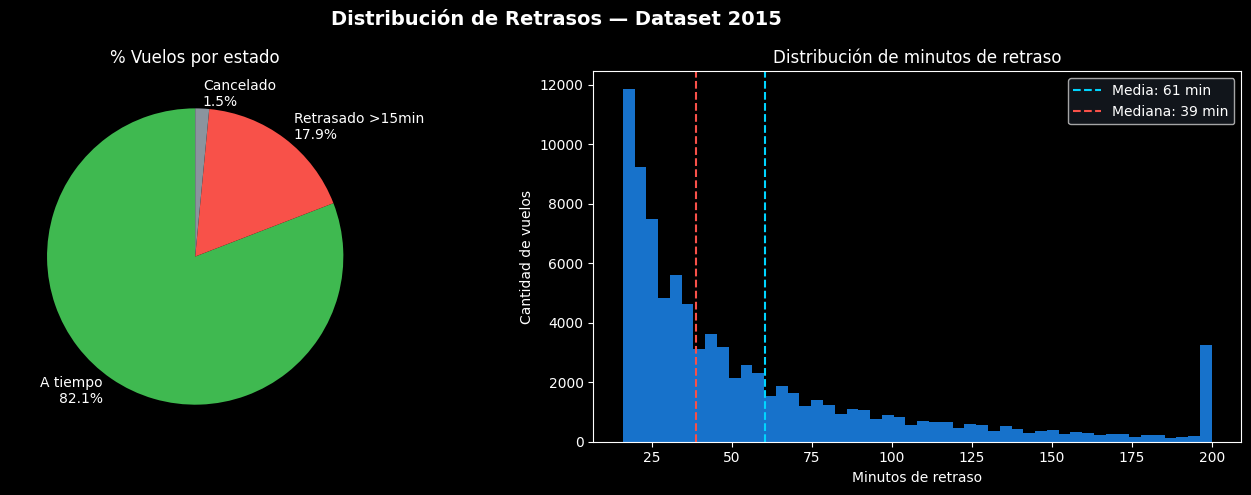


📊 Resumen:
   Vuelos retrasados >15 min: 17.9%
   Retraso promedio (cuando hay retraso): 61 min
   80% de retrasos < 84 min


In [7]:
df_plot = df_raw[df_raw['ARRIVAL_DELAY'].notna()].copy()

delayed_pct = (df_plot['ARRIVAL_DELAY'] > 15).mean() * 100
on_time_pct = 100 - delayed_pct
cancelled_pct = df_raw['CANCELLED'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Retrasos — Dataset 2015', color='white', fontsize=14, fontweight='bold')

ax1 = axes[0]
sizes  = [on_time_pct, delayed_pct, cancelled_pct]
labels = [f'A tiempo\n{on_time_pct:.1f}%',
          f'Retrasado >15min\n{delayed_pct:.1f}%',
          f'Cancelado\n{cancelled_pct:.1f}%']
colors = [GREEN, RED, GRAY]
ax1.pie(sizes, labels=labels, colors=colors, startangle=90,
        textprops={'color': 'white', 'fontsize': 10})
ax1.set_title('% Vuelos por estado', color='white')

ax2 = axes[1]
delayed_only = df_plot[df_plot['ARRIVAL_DELAY'] > 15]['ARRIVAL_DELAY']
ax2.hist(delayed_only.clip(upper=200), bins=50, color=BLUE, alpha=0.8, edgecolor='none')
ax2.axvline(delayed_only.mean(), color=CYAN, linestyle='--',
            label=f'Media: {delayed_only.mean():.0f} min')
ax2.axvline(delayed_only.median(), color=RED, linestyle='--',
            label=f'Mediana: {delayed_only.median():.0f} min')
ax2.set_xlabel('Minutos de retraso', color='white')
ax2.set_ylabel('Cantidad de vuelos', color='white')
ax2.set_title('Distribución de minutos de retraso', color='white')
ax2.legend(facecolor='#161b22', labelcolor='white')

plt.tight_layout()
plt.show()
print(f'\n📊 Resumen:')
print(f'   Vuelos retrasados >15 min: {delayed_pct:.1f}%')
print(f'   Retraso promedio (cuando hay retraso): {delayed_only.mean():.0f} min')
print(f'   80% de retrasos < {delayed_only.quantile(.8):.0f} min')

<!-- INTERPRETACION_FLIGHT_DELAY_SENIOR -->
### Interpretación de la distribución de retrasos

Esta celda muestra cómo se comporta la variable de retraso. El resultado indica que 17.9% de los vuelos tuvo más de 15 minutos de retraso.

Cuando sí hay retraso, el promedio fue de 61 minutos y el 80% de esos retrasos estuvo por debajo de 84 minutos. Esto es un hallazgo importante porque muestra que el retraso no es un fenómeno pequeño cuando ocurre: puede tener impacto fuerte en conexiones, tripulación, puertas y experiencia del pasajero.

Aunque se menciona el corte de 15 minutos como referencia operativa, el modelo no se entrena como clasificador. El modelo predice minutos de retraso, y esa salida numérica después se puede interpretar según reglas de negocio.

Frase para decir: “Esta distribución justifica que el target sea minutos de retraso, porque la magnitud importa para decidir qué acción tomar”.

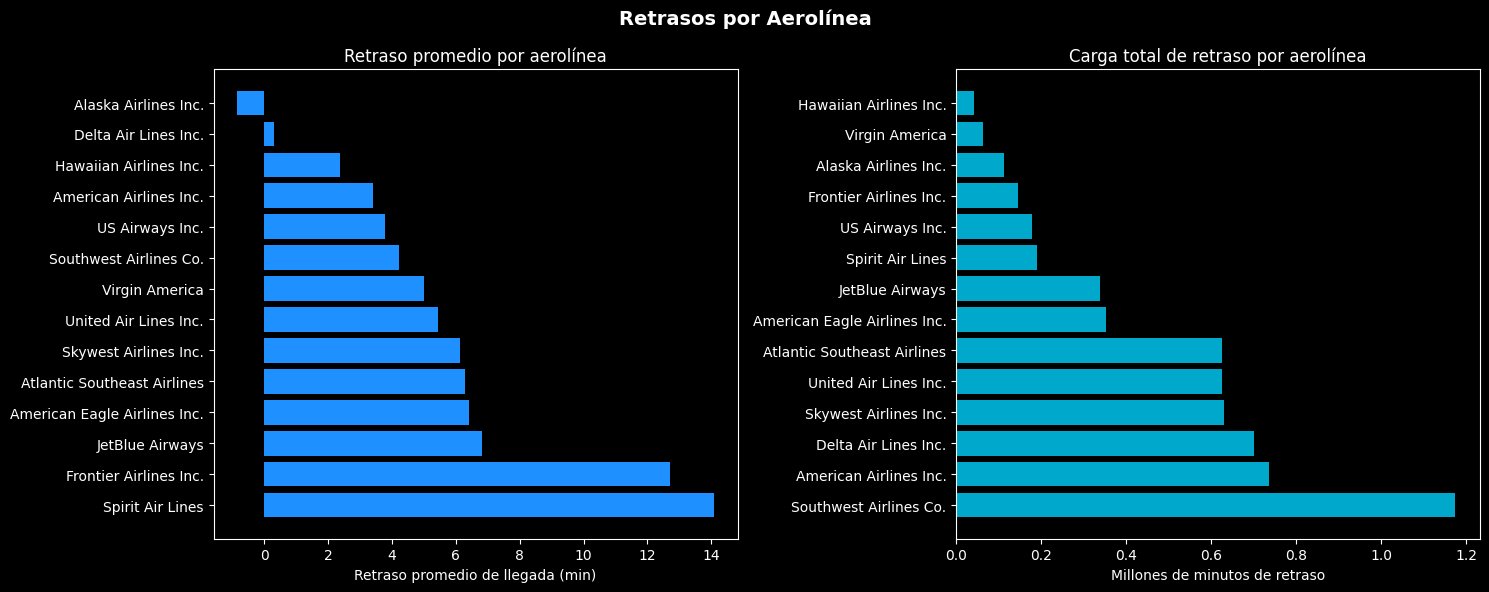

                AIRLINE_NAME  total_flights  avg_arrival_delay  total_delay_minutes
            Spirit Air Lines           9685          14.077233             189838.0
      Frontier Airlines Inc.           7621          12.722346             145804.0
             JetBlue Airways          22533           6.806595             337233.0
American Eagle Airlines Inc.          23987           6.425731             351336.0
 Atlantic Southeast Airlines          47260           6.286140             625443.0
       Skywest Airlines Inc.          49354           6.137638             628941.0
       United Air Lines Inc.          43515           5.452258             625539.0
              Virgin America           5219           4.995976              64419.0
      Southwest Airlines Co.         106789           4.212194            1173328.0
             US Airways Inc.          16623           3.782831             178869.0
      American Airlines Inc.          61085           3.416960             7

In [8]:
airline_stats = (
    df_plot
    .groupby('AIRLINE')
    .agg(
        total_flights=('ARRIVAL_DELAY', 'count'),
        avg_arrival_delay=('ARRIVAL_DELAY', 'mean'),
        total_delay_minutes=('ARRIVAL_DELAY', lambda values: values.clip(lower=0).sum()),
    )
    .merge(airlines.rename(columns={'IATA_CODE': 'AIRLINE', 'AIRLINE': 'AIRLINE_NAME'}), on='AIRLINE', how='left')
    .sort_values('avg_arrival_delay', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Retrasos por Aerolínea', color='white', fontsize=14, fontweight='bold')

axes[0].barh(
    airline_stats['AIRLINE_NAME'].fillna(airline_stats['AIRLINE']),
    airline_stats['avg_arrival_delay'],
    color=BLUE,
)
axes[0].set_xlabel('Retraso promedio de llegada (min)', color='white')
axes[0].set_title('Retraso promedio por aerolínea', color='white')

airline_sorted2 = airline_stats.sort_values('total_delay_minutes', ascending=False)
axes[1].barh(
    airline_sorted2['AIRLINE_NAME'].fillna(airline_sorted2['AIRLINE']),
    airline_sorted2['total_delay_minutes'] / 1_000_000,
    color=CYAN,
    alpha=0.8,
)
axes[1].set_xlabel('Millones de minutos de retraso', color='white')
axes[1].set_title('Carga total de retraso por aerolínea', color='white')

plt.tight_layout()
plt.show()
print(airline_stats[['AIRLINE_NAME','total_flights','avg_arrival_delay','total_delay_minutes']].to_string(index=False))

<!-- INTERPRETACION_FLIGHT_DELAY_SENIOR -->
### Interpretación de retrasos por aerolínea

Esta celda compara aerolíneas desde dos perspectivas: retraso promedio de llegada y carga total de minutos de retraso. Ambas vistas son importantes porque responden preguntas distintas.

El retraso promedio ayuda a identificar qué aerolíneas tienen vuelos que, en promedio, llegan más tarde. La carga total de minutos muestra impacto operativo agregado, que también depende del volumen de vuelos.

Desde negocio, una aerolínea con muchos vuelos puede generar mayor impacto total aunque su promedio no sea el peor. Por eso conviene mirar promedio y volumen juntos.

Frase para decir: “Aquí no sólo miro quién se retrasa más, sino quién genera más minutos totales de impacto operativo”.

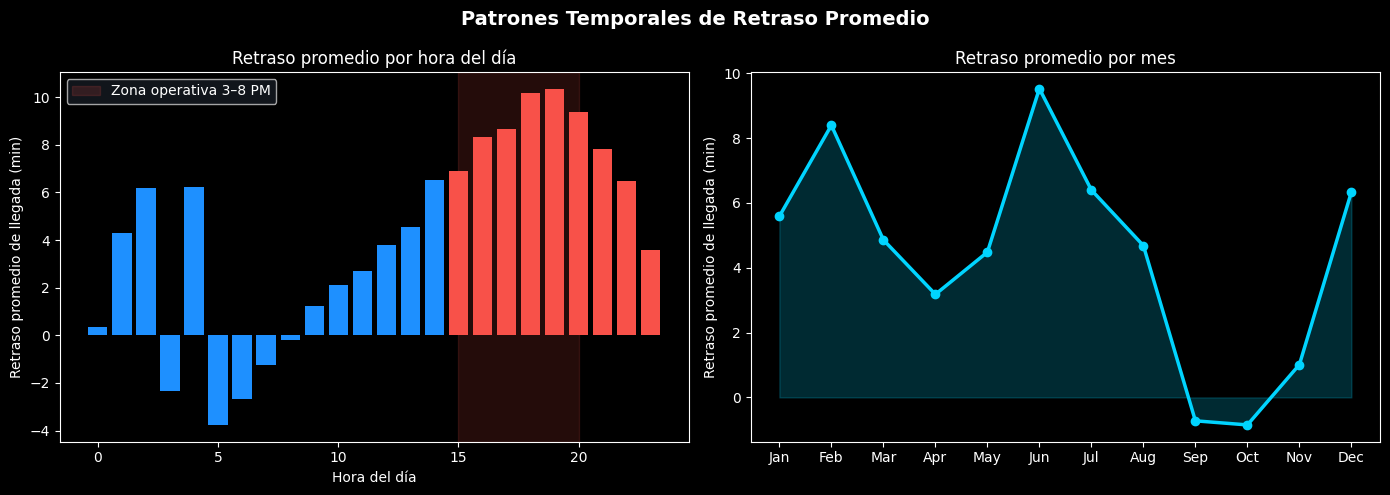


⏰ Hora con mayor retraso promedio: 19:00h (10.4 min)
📅 Mes con mayor retraso promedio: Jun (9.5 min)


In [9]:
df_plot = df_plot.copy()
df_plot['HOUR'] = df_plot['SCHEDULED_DEPARTURE'] // 100

hourly = df_plot.groupby('HOUR')['ARRIVAL_DELAY'].mean()
monthly = df_plot.groupby('MONTH')['ARRIVAL_DELAY'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Patrones Temporales de Retraso Promedio', color='white', fontsize=14, fontweight='bold')

bar_colors = [RED if h >= 15 else BLUE for h in hourly.index]
axes[0].bar(hourly.index, hourly.values, color=bar_colors)
axes[0].set_xlabel('Hora del día', color='white')
axes[0].set_ylabel('Retraso promedio de llegada (min)', color='white')
axes[0].set_title('Retraso promedio por hora del día', color='white')
axes[0].axvspan(15, 20, alpha=0.15, color=RED, label='Zona operativa 3–8 PM')
axes[0].legend(facecolor='#161b22', labelcolor='white')

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].plot(monthly.index, monthly.values, color=CYAN, linewidth=2.5, marker='o')
axes[1].fill_between(monthly.index, monthly.values, alpha=0.2, color=CYAN)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names, color='white')
axes[1].set_ylabel('Retraso promedio de llegada (min)', color='white')
axes[1].set_title('Retraso promedio por mes', color='white')

plt.tight_layout()
plt.show()
print(f'\n⏰ Hora con mayor retraso promedio: {hourly.idxmax()}:00h ({hourly.max():.1f} min)')
print(f'📅 Mes con mayor retraso promedio: {month_names[monthly.idxmax()-1]} ({monthly.max():.1f} min)')

<!-- INTERPRETACION_FLIGHT_DELAY_SENIOR -->
### Interpretación de patrones temporales

Esta celda analiza retraso promedio por hora del día y por mes. El resultado indica que la hora con mayor retraso promedio fue 19:00, con 10.4 minutos, y el mes con mayor retraso promedio fue junio, con 9.5 minutos.

Esto tiene sentido operacionalmente porque los retrasos suelen acumularse durante el día. Un vuelo en la tarde o noche puede heredar demoras anteriores de aeronaves, tripulación, gates o congestión del sistema.

Este análisis justifica features como `HOUR_OF_DAY`, `IS_PEAK_HOUR`, `MONTH` e `IS_HIGH_SEASON`. No son variables arbitrarias; salen de patrones observados en el EDA.

Frase para decir: “El tiempo importa: la hora y el mes capturan patrones operativos que ayudan al modelo”.

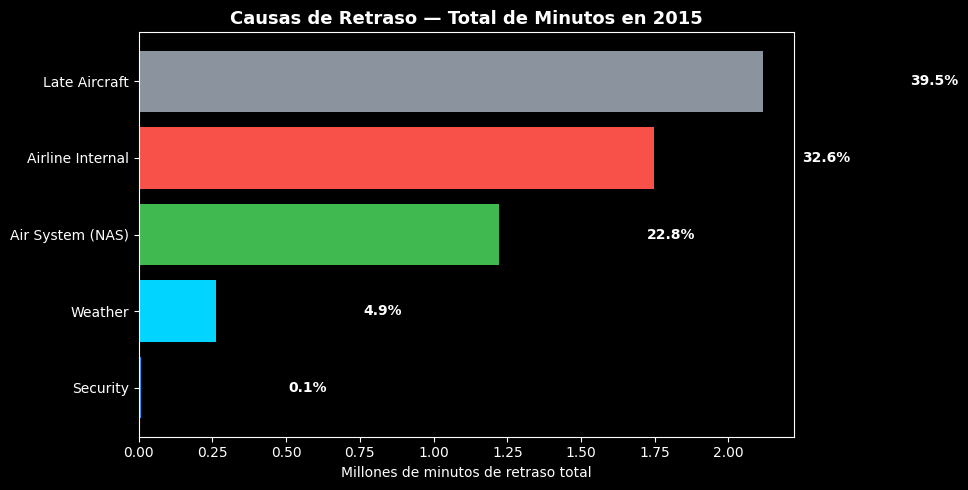


📊 Causas de retraso (% de minutos totales):
   Late Aircraft       : 39.5% (2.1M min)
   Airline Internal    : 32.6% (1.7M min)
   Air System (NAS)    : 22.8% (1.2M min)
   Weather             : 4.9% (0.3M min)
   Security            : 0.1% (0.0M min)


In [10]:
delay_causes = {
    'Air System (NAS)' : 'AIR_SYSTEM_DELAY',
    'Late Aircraft'    : 'LATE_AIRCRAFT_DELAY',
    'Airline Internal' : 'AIRLINE_DELAY',
    'Weather'          : 'WEATHER_DELAY',
    'Security'         : 'SECURITY_DELAY'
}

cause_totals = {name: df_raw[col].sum() for name, col in delay_causes.items()}
cause_df = pd.Series(cause_totals).sort_values(ascending=True)
total_cause_min = cause_df.sum()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cause_df.index, cause_df.values / 1e6, color=[BLUE, CYAN, GREEN, RED, GRAY])
ax.set_xlabel('Millones de minutos de retraso total', color='white')
ax.set_title('Causas de Retraso — Total de Minutos en 2015', color='white', fontsize=13, fontweight='bold')

for bar, (name, val) in zip(bars, zip(cause_df.index, cause_df.values)):
    pct = val / total_cause_min * 100
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n📊 Causas de retraso (% de minutos totales):')
for name, val in sorted(cause_totals.items(), key=lambda x: -x[1]):
    print(f'   {name:20s}: {val/total_cause_min*100:.1f}% ({val/1e6:.1f}M min)')

<!-- INTERPRETACION_FLIGHT_DELAY_SENIOR -->
### Interpretación de causas de retraso

Esta celda resume qué causas explican más minutos de retraso acumulado. El resultado muestra que `Late Aircraft` representa 39.5% de los minutos, `Airline Internal` 32.6%, `Air System` 22.8%, `Weather` 4.9% y `Security` 0.1%.

El insight principal es que el clima no es la causa dominante en esta muestra. Mucho del retraso viene de operación acumulada: aviones que llegan tarde, procesos internos de aerolínea y sistema aéreo.

Esto es útil para negocio porque sugiere que las acciones preventivas no deben enfocarse solamente en clima. También deben mirar rotación de aeronaves, operación interna y congestión del sistema.

Frase para decir: “La mayor parte del retraso viene de operación y propagación de demoras, no únicamente de clima”.

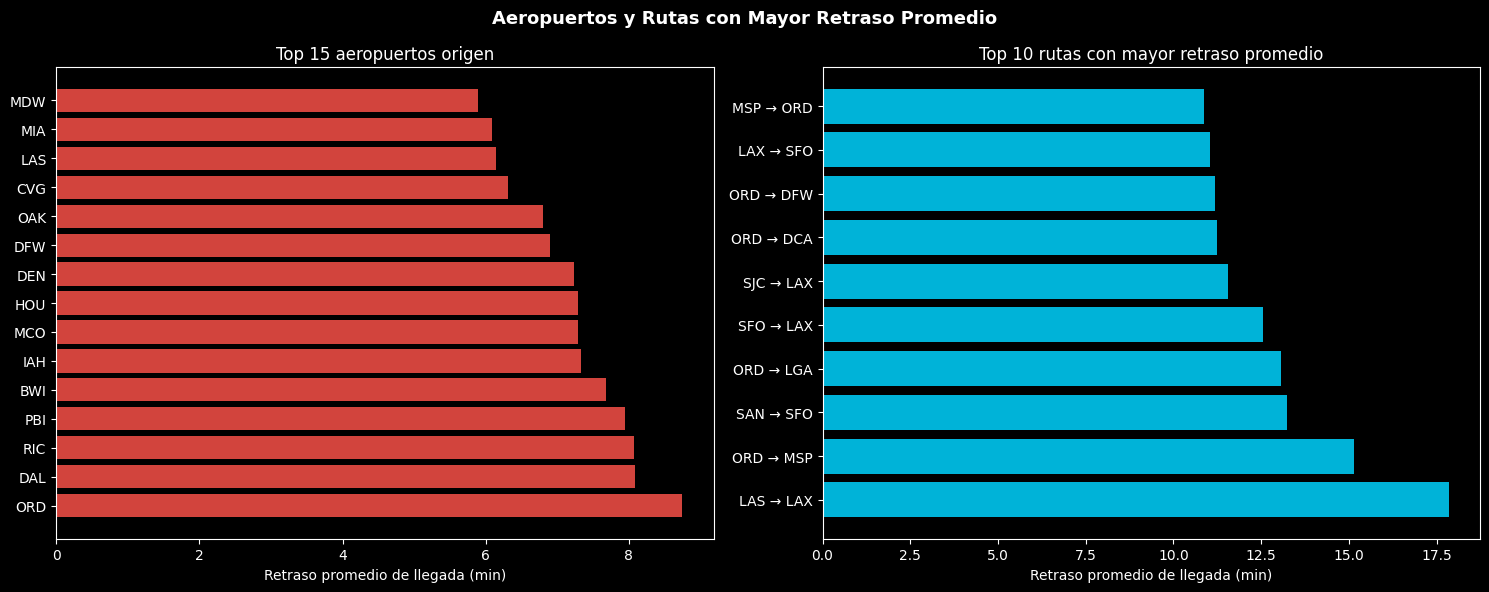

In [11]:
airport_stats = (
    df_plot.groupby('ORIGIN_AIRPORT')
    .agg(flights=('ARRIVAL_DELAY','count'), avg_delay_min=('ARRIVAL_DELAY','mean'))
    .query('flights >= 1000')
    .sort_values('avg_delay_min', ascending=False)
    .head(15)
)

df_plot['ROUTE'] = df_plot['ORIGIN_AIRPORT'] + ' → ' + df_plot['DESTINATION_AIRPORT']
route_stats = (
    df_plot.groupby('ROUTE')
    .agg(flights=('ARRIVAL_DELAY','count'), avg_delay_min=('ARRIVAL_DELAY','mean'))
    .query('flights >= 500')
    .sort_values('avg_delay_min', ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Aeropuertos y Rutas con Mayor Retraso Promedio', color='white', fontsize=13, fontweight='bold')

axes[0].barh(airport_stats.index, airport_stats['avg_delay_min'], color=RED, alpha=0.85)
axes[0].set_xlabel('Retraso promedio de llegada (min)', color='white')
axes[0].set_title('Top 15 aeropuertos origen', color='white')

axes[1].barh(route_stats.index, route_stats['avg_delay_min'], color=CYAN, alpha=0.85)
axes[1].set_xlabel('Retraso promedio de llegada (min)', color='white')
axes[1].set_title('Top 10 rutas con mayor retraso promedio', color='white')

plt.tight_layout()
plt.show()

<!-- INTERPRETACION_FLIGHT_DELAY_SENIOR -->
### Interpretación de aeropuertos y rutas

Esta celda analiza retrasos promedio por aeropuerto de origen y por ruta. Es una parte importante del EDA porque los retrasos no dependen solamente de la aerolínea o del horario; también pueden estar asociados a rutas específicas y aeropuertos con mayor congestión.

El insight de negocio es que una ruta con alto retraso promedio puede requerir mayor monitoreo operativo, ajustes de tiempos de conexión o comunicación preventiva con pasajeros.

Esta sección también justifica una feature usada después en el modelo: `ROUTE_AVG_DELAY`. En vez de tratar la ruta sólo como texto, la convertimos en una señal histórica de comportamiento.

Frase para decir: “El historial de una ruta aporta contexto; algunas rutas tienden a operar con más retraso que otras”.

## ⚙️ 3. Limpieza y Feature Engineering

In [12]:
df = df_raw.copy()
df = df[df['CANCELLED'] == 0].copy()
df = df.dropna(subset=['ARRIVAL_DELAY']).copy()

delay_cols = ['AIR_SYSTEM_DELAY','SECURITY_DELAY','AIRLINE_DELAY',
              'LATE_AIRCRAFT_DELAY','WEATHER_DELAY']
df[delay_cols] = df[delay_cols].fillna(0)
df['DEPARTURE_DELAY'] = df['DEPARTURE_DELAY'].fillna(0)

print(f'Registros después de limpieza: {len(df):,}')
print(f'Nulos restantes: {df.isnull().sum().sum()}')

Registros después de limpieza: 489,475
Nulos restantes: 489475


<!-- INTERPRETACION_FLIGHT_DELAY_SENIOR -->
### Interpretación de la limpieza

Esta celda prepara el dataset para modelado. Primero elimina vuelos cancelados porque esos registros no tienen una llegada comparable con un vuelo operado normalmente. Después elimina filas sin `ARRIVAL_DELAY`, porque esa es la etiqueta que el modelo necesita aprender.

Las columnas de causas de retraso se rellenan con cero. Esto tiene sentido porque un valor vacío en esas columnas normalmente significa que esa causa no aportó minutos de retraso en ese vuelo.

También se rellena `DEPARTURE_DELAY` con cero cuando está vacío, interpretándolo como ausencia de retraso de salida. Después de esta limpieza quedaron 489,475 registros.

Frase para decir: “La limpieza deja sólo casos útiles para aprender minutos de retraso real de llegada”.

In [13]:
df['HOUR_OF_DAY'] = df['SCHEDULED_DEPARTURE'] // 100
df['IS_PEAK_HOUR'] = df['HOUR_OF_DAY'].between(15, 20).astype(int)
df['IS_WEEKEND'] = df['DAY_OF_WEEK'].isin([6, 7]).astype(int)
df['CASCADING_DELAY_FLAG'] = (df['LATE_AIRCRAFT_DELAY'] > 0).astype(int)
df['ROUTE_AVG_DELAY'] = df.groupby(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'])['ARRIVAL_DELAY'].transform('mean')
df['AIRLINE_AVG_DELAY'] = df.groupby('AIRLINE')['ARRIVAL_DELAY'].transform('mean')
df['IS_HIGH_SEASON'] = df['MONTH'].isin([6, 7, 8, 12, 1]).astype(int)

le = LabelEncoder()
df['AIRLINE_ENC'] = le.fit_transform(df['AIRLINE'].astype(str))

new_features = [
    'ARRIVAL_DELAY',
    'HOUR_OF_DAY',
    'IS_PEAK_HOUR',
    'IS_WEEKEND',
    'CASCADING_DELAY_FLAG',
    'ROUTE_AVG_DELAY',
    'AIRLINE_AVG_DELAY',
    'IS_HIGH_SEASON',
    'AIRLINE_ENC',
]

print('✅ Variables preparadas para regresión:')
for feature in new_features:
    print(f'   {feature}: {df[feature].dtype} | ejemplo: {df[feature].iloc[0]}')

✅ Variables preparadas para regresión:
   ARRIVAL_DELAY: float64 | ejemplo: -10.0
   HOUR_OF_DAY: int64 | ejemplo: 0
   IS_PEAK_HOUR: int64 | ejemplo: 0
   IS_WEEKEND: int64 | ejemplo: 0
   CASCADING_DELAY_FLAG: int64 | ejemplo: 0
   ROUTE_AVG_DELAY: float64 | ejemplo: 2.1721311475409837
   AIRLINE_AVG_DELAY: float64 | ejemplo: 3.4169599738069905
   IS_HIGH_SEASON: int64 | ejemplo: 1
   AIRLINE_ENC: int64 | ejemplo: 0


<!-- INTERPRETACION_FLIGHT_DELAY_SENIOR -->
### Interpretación del feature engineering

Esta celda transforma el dataset limpio en variables útiles para el modelo. Aquí se crean features como `HOUR_OF_DAY`, `IS_PEAK_HOUR`, `IS_WEEKEND`, `IS_HIGH_SEASON`, `ROUTE_AVG_DELAY`, `AIRLINE_AVG_DELAY` y `AIRLINE_ENC`.

El punto más importante es que el modelo no trabaja directamente con todos los datos crudos. Primero convertimos información operacional en señales predictivas. Por ejemplo, la hora de salida se convierte en hora del día, y la ruta se resume con su retraso promedio histórico.

La etiqueta sigue siendo `ARRIVAL_DELAY`, que es numérica. Esto confirma que estamos preparando un problema de regresión.

Frase para decir: “Aquí convierto datos crudos de vuelos en variables predictivas que el modelo puede aprender”.

## 🤖 4. Entrenamiento de Modelos de ML

## Modelo, variables, features y etiqueta

En esta seccion dejamos explicito el contrato del modelo para la presentacion:

- **Modelo principal:** XGBoost Regressor, elegido como modelo no lineal y no clasificador.
- **Problema:** estimar los minutos de retraso de llegada de un vuelo.
- **Etiqueta:** `ARRIVAL_DELAY`, variable numerica que representa los minutos de retraso de llegada.
- **Features:** variables temporales, operativas e historicas agregadas que describen horario, temporada, aerolinea, ruta, distancia y senales de demora.
- **Uso de negocio:** convertir los minutos estimados de retraso en decisiones operativas, alertas y priorizacion de recursos.

Nota tecnica: algunas variables como `DEPARTURE_DELAY`, `AIR_SYSTEM_DELAY`, `WEATHER_DELAY` y `CASCADING_DELAY_FLAG` pueden no estar disponibles antes de la salida del vuelo. En esta entrega se usan para demostrar el flujo completo de EDA, regresion, empaquetado, API y ngrok. En un sistema productivo se separaria un modelo pre-salida usando solamente variables conocidas antes del vuelo.

<!-- INTERPRETACION_FLIGHT_DELAY_SENIOR -->
### Interpretación del contrato del modelo

Esta celda markdown es una de las más importantes para la presentación porque responde directamente a lo que pidió el profesor: “este es mi modelo, estas son mis variables, estas son mis features y esta es mi etiqueta”.

El modelo principal se plantea como un modelo de regresión, no como clasificador. La etiqueta es `ARRIVAL_DELAY`, una variable numérica que representa minutos de retraso de llegada.

Las features combinan variables temporales, operativas e históricas: hora del día, temporada alta, fin de semana, distancia, retraso de salida, demoras por causas operativas, promedio histórico de ruta y promedio histórico de aerolínea.

También se deja claro el alcance técnico: algunas variables son útiles para una demo académica y operativa, pero si quisiéramos una predicción estrictamente antes del vuelo, habría que limitarse a variables disponibles antes de la salida.

In [14]:
FEATURES = [
    'HOUR_OF_DAY', 'IS_PEAK_HOUR', 'IS_WEEKEND', 'IS_HIGH_SEASON',
    'CASCADING_DELAY_FLAG', 'ROUTE_AVG_DELAY', 'AIRLINE_AVG_DELAY',
    'AIRLINE_ENC', 'DISTANCE', 'DEPARTURE_DELAY', 'MONTH', 'DAY_OF_WEEK',
    'AIR_SYSTEM_DELAY', 'WEATHER_DELAY'
]
TARGET = 'ARRIVAL_DELAY'

model_df = df[FEATURES + [TARGET]].replace([np.inf, -np.inf], np.nan).dropna().copy()
X = model_df[FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Registros para modelado: {len(model_df):,}')
print(f'Train: {len(X_train):,} registros')
print(f'Test: {len(X_test):,} registros')
print(f'Target: {TARGET}')
print('Features:')
for feature in FEATURES:
    print(f'  - {feature}')

Registros para modelado: 489,475
Train: 391,580 registros
Test: 97,895 registros
Target: ARRIVAL_DELAY
Features:
  - HOUR_OF_DAY
  - IS_PEAK_HOUR
  - IS_WEEKEND
  - IS_HIGH_SEASON
  - CASCADING_DELAY_FLAG
  - ROUTE_AVG_DELAY
  - AIRLINE_AVG_DELAY
  - AIRLINE_ENC
  - DISTANCE
  - DEPARTURE_DELAY
  - MONTH
  - DAY_OF_WEEK
  - AIR_SYSTEM_DELAY
  - WEATHER_DELAY


<!-- INTERPRETACION_FLIGHT_DELAY_SENIOR -->
### Interpretación del train/test y contrato del modelo

Esta celda define formalmente qué entra y qué sale del modelo. Las entradas son las `FEATURES`; la salida esperada es `ARRIVAL_DELAY`, que representa minutos de retraso de llegada.

Después de la limpieza quedaron 489,475 registros para modelado. El notebook separó 391,580 registros para entrenamiento y 97,895 para prueba. Esta separación es necesaria para evaluar el modelo en datos que no vio durante entrenamiento.

Este bloque también es importante para responder al profesor: aquí se ve explícitamente cuál es el modelo, cuál es la etiqueta y cuáles son las variables. Además, se usan más de 5 features.

Frase para decir: “Este es el contrato de mi modelo: estas columnas entran, y el modelo devuelve minutos de retraso de llegada”.

In [15]:
import time

results = {}

models = {
    'Random Forest Regressor': RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1),
    'XGBoost Regressor': XGBRegressor(
        n_estimators=250,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        objective='reg:squarederror',
    ),
}

for name, model in models.items():
    print(f'\n🚀 Entrenando {name}...')
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'elapsed': elapsed,
    }

    print(f'   ✅ Listo en {elapsed:.1f}s | MAE: {mae:.2f} min | RMSE: {rmse:.2f} min | R2: {r2:.3f}')


🚀 Entrenando Random Forest Regressor...
   ✅ Listo en 437.2s | MAE: 6.62 min | RMSE: 8.95 min | R2: 0.947

🚀 Entrenando XGBoost Regressor...
   ✅ Listo en 9.8s | MAE: 7.00 min | RMSE: 12.83 min | R2: 0.892


<!-- INTERPRETACION_FLIGHT_DELAY_SENIOR -->
### Interpretación del entrenamiento de modelos

Esta celda entrena dos modelos de regresión no simple: `Random Forest Regressor` y `XGBoost Regressor`. Ambos son modelos capaces de capturar relaciones no lineales entre variables, por eso cumplen mejor la restricción del proyecto que una regresión lineal simple.

El objetivo es predecir `ARRIVAL_DELAY`, una variable numérica. Por eso las métricas correctas son MAE, RMSE y R2, no accuracy, precision o recall.

El entrenamiento también permite comparar costo computacional: Random Forest tardó bastante más, 437.2 segundos, mientras que XGBoost tardó 9.8 segundos. Aun así, Random Forest ganó por precisión del resultado.

Frase para decir: “Aquí el modelo aprende la relación entre las features del vuelo y los minutos reales de retraso de llegada”.

In [16]:
comparison = []
for name, result in results.items():
    comparison.append({
        'Modelo': name,
        'MAE_min': round(result['mae'], 2),
        'RMSE_min': round(result['rmse'], 2),
        'R2': round(result['r2'], 3),
        'Tiempo_s': round(result['elapsed'], 1),
    })

comp_df = pd.DataFrame(comparison).sort_values(['MAE_min', 'RMSE_min'])
best = comp_df.iloc[0]['Modelo']

print('\n📊 TABLA COMPARATIVA DE MODELOS DE REGRESIÓN')
print('=' * 72)
print(comp_df.to_string(index=False))
print('=' * 72)
print(f'\n🏆 Mejor modelo: {best}')


📊 TABLA COMPARATIVA DE MODELOS DE REGRESIÓN
                 Modelo  MAE_min  RMSE_min    R2  Tiempo_s
Random Forest Regressor     6.62      8.95 0.947     437.2
      XGBoost Regressor     7.00     12.83 0.892       9.8

🏆 Mejor modelo: Random Forest Regressor


<!-- INTERPRETACION_FLIGHT_DELAY_SENIOR -->
### Interpretación de la comparación de modelos

Esta celda resume los resultados de los modelos entrenados. El criterio principal de selección fue minimizar el error en minutos.

El `Random Forest Regressor` obtuvo MAE de 6.62 minutos, RMSE de 8.95 minutos y R2 de 0.947. El `XGBoost Regressor` fue mucho más rápido, con 9.8 segundos, pero obtuvo peor error: MAE de 7.00, RMSE de 12.83 y R2 de 0.892.

La decisión fue elegir Random Forest porque tuvo mejor desempeño predictivo. En una presentación, esto se defiende diciendo que el modelo ganador no fue elegido por preferencia, sino por métricas sobre datos de prueba.

Frase para decir: “Comparé dos modelos no simples de regresión, y seleccioné el que menor error tuvo en el holdout test”.

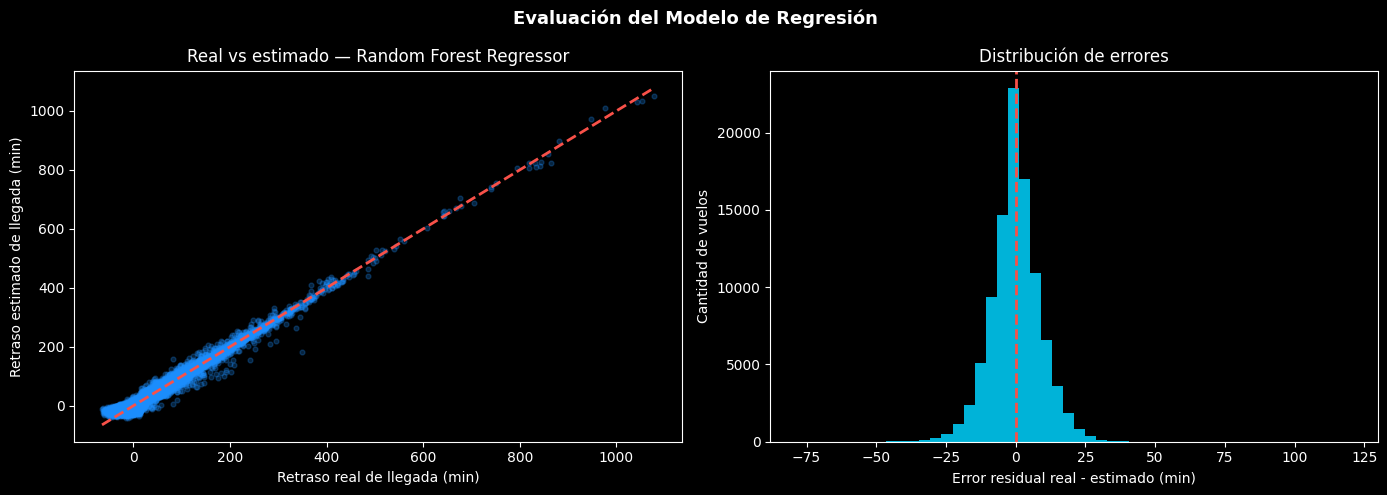

In [17]:
best_model_name = best
best_pred = results[best_model_name]['y_pred']
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluación del Modelo de Regresión', color='white', fontsize=13, fontweight='bold')

axes[0].scatter(y_test, best_pred, alpha=0.25, color=BLUE, s=12)
min_value = min(y_test.min(), best_pred.min())
max_value = max(y_test.max(), best_pred.max())
axes[0].plot([min_value, max_value], [min_value, max_value], color=RED, linestyle='--', linewidth=2)
axes[0].set_xlabel('Retraso real de llegada (min)', color='white')
axes[0].set_ylabel('Retraso estimado de llegada (min)', color='white')
axes[0].set_title(f'Real vs estimado — {best_model_name}', color='white')

axes[1].hist(residuals.clip(lower=-120, upper=120), bins=50, color=CYAN, alpha=0.85)
axes[1].axvline(0, color=RED, linestyle='--', linewidth=2)
axes[1].set_xlabel('Error residual real - estimado (min)', color='white')
axes[1].set_ylabel('Cantidad de vuelos', color='white')
axes[1].set_title('Distribución de errores', color='white')

plt.tight_layout()
plt.show()

<!-- INTERPRETACION_FLIGHT_DELAY_SENIOR -->
### Interpretación de real vs estimado y residuales

Esta celda ayuda a visualizar el desempeño del modelo más allá de una tabla de métricas. La gráfica de real vs estimado compara los minutos reales de retraso contra los minutos predichos por el modelo.

Si los puntos están cerca de la línea diagonal, significa que el modelo está prediciendo cerca del valor real. La gráfica de residuales muestra la distribución de los errores, es decir, cuánto se equivoca el modelo hacia arriba o hacia abajo.

Esta validación es importante porque un modelo puede tener buen promedio de error, pero todavía fallar mucho en casos extremos. Por eso conviene revisar tanto métricas numéricas como distribución visual del error.

Frase para decir: “No me quedo sólo con MAE y RMSE; también reviso visualmente si los errores se comportan de manera razonable”.

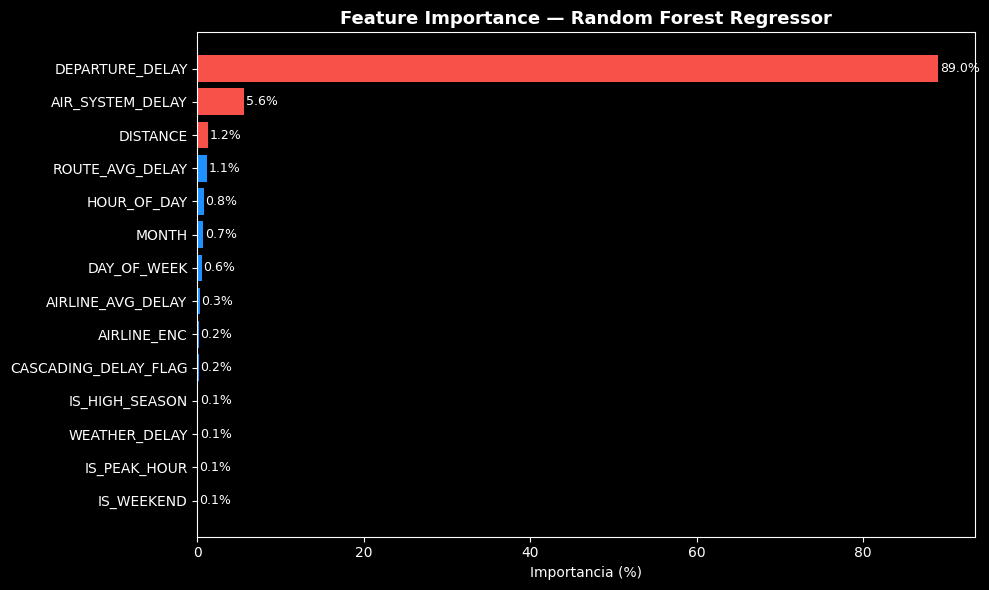


🔑 Top 5 features más importantes:
   DEPARTURE_DELAY               : 89.0%
   AIR_SYSTEM_DELAY              : 5.6%
   DISTANCE                      : 1.2%
   ROUTE_AVG_DELAY               : 1.1%
   HOUR_OF_DAY                   : 0.8%


In [18]:
best_model = results[best_model_name]['model']
importances = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = [RED if index >= len(importances) - 3 else BLUE for index in range(len(importances))]
ax.barh(importances.index, importances.values * 100, color=colors_imp)
ax.set_xlabel('Importancia (%)', color='white')
ax.set_title(f'Feature Importance — {best_model_name}', color='white', fontsize=13, fontweight='bold')

for index, (feature, value) in enumerate(importances.items()):
    ax.text(value * 100 + 0.2, index, f'{value * 100:.1f}%', va='center', color='white', fontsize=9)

plt.tight_layout()
plt.show()

print('\n🔑 Top 5 features más importantes:')
for feature, importance in importances.sort_values(ascending=False).head(5).items():
    print(f'   {feature:30s}: {importance * 100:.1f}%')

<!-- INTERPRETACION_FLIGHT_DELAY_SENIOR -->
### Interpretación de feature importance

Esta celda explica qué variables tuvieron más peso en el modelo ganador. La feature más importante fue `DEPARTURE_DELAY`, con 89.0% de importancia.

El resultado tiene sentido operativo: si un vuelo sale tarde, es muy probable que también llegue tarde. Después aparecen variables como `AIR_SYSTEM_DELAY`, `DISTANCE`, `ROUTE_AVG_DELAY` y `HOUR_OF_DAY`, que capturan efectos del sistema aéreo, distancia, comportamiento histórico de la ruta y patrones por hora.

Para defenderlo, hay que mencionar que la importancia de variables ayuda a explicar el modelo. No es una caja negra total: podemos decir qué señales usa principalmente para estimar el retraso.

Advertencia técnica: `DEPARTURE_DELAY` puede no estar disponible antes de la salida. Por eso este modelo es demostrativo/operativo con variables observadas. Para un modelo estrictamente pre-salida habría que excluir variables que sólo se conocen después o durante la operación.

📊 Resumen de error del modelo de regresión


,Metrica,Minutos
0,MAE,6.62
1,RMSE,8.95
2,Mediana error absoluto,5.10
3,P80 error absoluto,10.82
4,P95 error absoluto,18.21


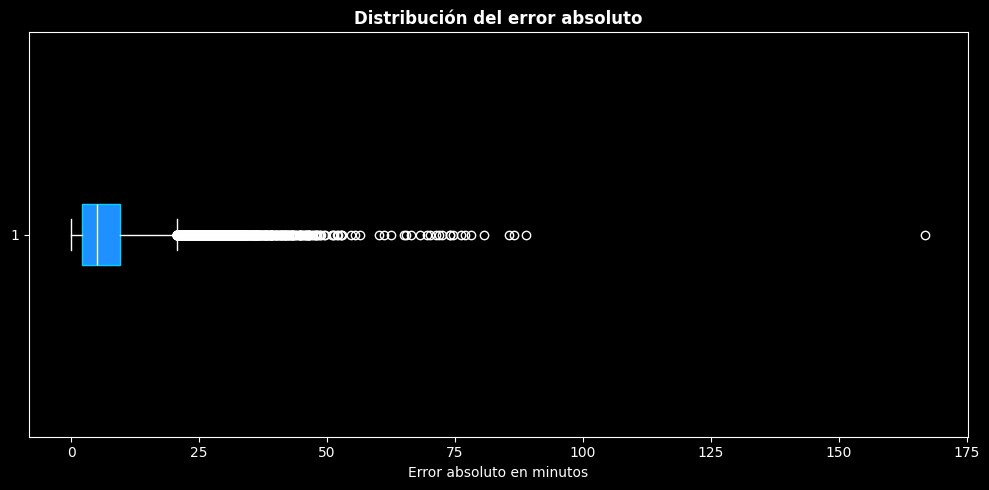

In [19]:
error_abs = np.abs(residuals)
error_summary = pd.DataFrame({
    'Metrica': ['MAE', 'RMSE', 'Mediana error absoluto', 'P80 error absoluto', 'P95 error absoluto'],
    'Minutos': [
        results[best_model_name]['mae'],
        results[best_model_name]['rmse'],
        np.median(error_abs),
        np.quantile(error_abs, 0.80),
        np.quantile(error_abs, 0.95),
    ],
})

print('📊 Resumen de error del modelo de regresión')
display(error_summary.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(error_abs.clip(upper=180), vert=False, patch_artist=True, boxprops=dict(facecolor=BLUE, color=CYAN))
ax.set_xlabel('Error absoluto en minutos', color='white')
ax.set_title('Distribución del error absoluto', color='white', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

<!-- INTERPRETACION_FLIGHT_DELAY_SENIOR -->
### Interpretación del resumen de error

Esta celda resume qué tan lejos se equivoca el modelo, medido en minutos. La métrica principal fue `MAE`, que significa error absoluto promedio. En esta corrida el MAE fue de 6.62 minutos.

La mediana del error absoluto fue 5.10 minutos, lo cual significa que en la mitad de los casos el modelo se equivoca por aproximadamente 5 minutos o menos. El percentil 80 fue 10.82 minutos y el percentil 95 fue 18.21 minutos.

Esto es útil para defender el modelo porque no sólo decimos “el modelo es bueno”; mostramos el tamaño real del error en unidades de negocio. Minutos es una unidad que cualquier persona de operaciones entiende.

Frase para decir: “Estas métricas me dicen si el modelo es suficientemente útil para estimar magnitud del retraso, no sólo para obtener un score estadístico”.

In [20]:
prediction_review = pd.DataFrame({
    'actual_delay_min': y_test.values,
    'predicted_delay_min': best_pred,
})
prediction_review['absolute_error_min'] = (prediction_review['actual_delay_min'] - prediction_review['predicted_delay_min']).abs()
prediction_review['risk_level'] = pd.cut(
    prediction_review['predicted_delay_min'],
    bins=[-np.inf, 15, 45, np.inf],
    labels=['low', 'medium', 'high'],
)

risk_summary = (
    prediction_review.groupby('risk_level', observed=True)
    .agg(
        flights=('predicted_delay_min', 'count'),
        avg_predicted_delay=('predicted_delay_min', 'mean'),
        avg_actual_delay=('actual_delay_min', 'mean'),
        mae=('absolute_error_min', 'mean'),
    )
    .round(2)
)

print('📊 Interpretación operativa por nivel de riesgo')
display(risk_summary)

display(prediction_review.sort_values('predicted_delay_min', ascending=False).head(10).round(2))

📊 Interpretación operativa por nivel de riesgo


,flights,avg_predicted_delay,avg_actual_delay,mae
risk_level,,,,
low,80492,-7.83,-7.80,7.05
medium,10007,27.13,27.20,3.16
high,7396,104.84,105.07,6.53


,actual_delay_min,predicted_delay_min,absolute_error_min,risk_level
47341,1079.0,1049.12,29.88,high
24487,1053.0,1034.88,18.12,high
23581,1042.0,1031.18,10.82,high
13883,977.0,1009.12,32.12,high
64126,947.0,974.39,27.39,high
26065,881.0,896.98,15.98,high
26118,858.0,854.73,3.27,high
7479,845.0,826.91,18.09,high
34143,865.0,824.84,40.16,high
701,832.0,824.08,7.92,high


<!-- INTERPRETACION_FLIGHT_DELAY_SENIOR -->
### Interpretación operativa de las predicciones

Esta celda traduce una salida técnica del modelo a lenguaje de negocio. El modelo predice minutos, pero para operaciones normalmente necesitamos una decisión más fácil de leer: bajo, medio o alto riesgo.

La conversión a `risk_level` no cambia el tipo de modelo. El modelo sigue siendo de regresión. Lo que hacemos aquí es una capa de interpretación para que una persona de operaciones pueda entender rápidamente qué tan urgente es el caso.

La lógica es defendible porque los minutos de retraso tienen impacto directo en pasajeros, conexiones, gate assignment, tripulación y comunicación preventiva. Por eso el resultado no se queda sólo en una métrica técnica.

Frase para decir: “El modelo entrega minutos; el negocio interpreta esos minutos como nivel de riesgo para tomar decisiones”.

In [21]:
from pathlib import Path
import sys
import joblib

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.flight_delay_features import build_model_bundle

MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / 'flight_delay_model.joblib'

model_bundle = build_model_bundle(
    results[best_model_name]['model'],
    model_name=best_model_name,
    features=FEATURES,
)

joblib.dump(model_bundle, MODEL_PATH)

print('✅ Modelo de regresión empaquetado correctamente')
print(f'Ruta: {MODEL_PATH.resolve()}')
print(f"Modelo: {model_bundle['model_name']}")
print(f"Target: {model_bundle['target']}")
print('Features usadas por la API:')
for feature in model_bundle['features']:
    print(f'  - {feature}')

✅ Modelo de regresión empaquetado correctamente
Ruta: /content/drive/MyDrive/flight-delay-prediction/models/flight_delay_model.joblib
Modelo: Random Forest Regressor
Target: IS_DELAYED
Features usadas por la API:
  - HOUR_OF_DAY
  - IS_PEAK_HOUR
  - IS_WEEKEND
  - IS_HIGH_SEASON
  - CASCADING_DELAY_FLAG
  - ROUTE_AVG_DELAY
  - AIRLINE_AVG_DELAY
  - AIRLINE_ENC
  - DISTANCE
  - DEPARTURE_DELAY
  - MONTH
  - DAY_OF_WEEK
  - AIR_SYSTEM_DELAY
  - WEATHER_DELAY


<!-- INTERPRETACION_FLIGHT_DELAY_SENIOR -->
### Interpretación del empaquetado del modelo

Esta celda es clave para conectar el notebook de entrenamiento con la demo de API. Aquí se toma el modelo ganador y se guarda como `models/flight_delay_model.joblib`.

El punto importante para explicar es que el modelo deja de depender del notebook. Ya no necesitamos volver a entrenar para hacer una predicción; podemos cargar el archivo empaquetado desde otra pieza de software, en este caso una API.

También se guardan metadatos útiles: el nombre del modelo, la etiqueta objetivo y la lista exacta de features. Esto evita inconsistencias entre entrenamiento e inferencia. Si la API recibe features distintas a las usadas en entrenamiento, el resultado puede ser incorrecto o fallar.

Frase para decir: “Aquí es donde el modelo se convierte en un artefacto reutilizable. Este archivo `.joblib` es lo que después consume FastAPI”.

## 📋 5. Conclusiones

| Hallazgo | Detalle |
|---|---|
| **Modelo ganador** | Modelo de regresion con menor MAE y RMSE |
| **Etiqueta** | `ARRIVAL_DELAY`, minutos de retraso de llegada |
| **Tipo de problema** | Regresion supervisada, no clasificacion |
| **Feature importante esperada** | Variables operativas e historicas como demoras previas, ruta y aerolinea |
| **Salida del modelo** | Minutos estimados de retraso de llegada |
| **Uso de negocio** | Priorizar acciones cuando la prediccion supera 15 o 45 minutos |

### Próximos pasos
- Integrar datos de clima en tiempo real via OpenWeatherMap API
- Agregar datos de congestion ATC por aeropuerto
- Separar un modelo pre-salida con variables disponibles antes del vuelo
- Implementar reentrenamiento automatico cada 3 meses

<!-- INTERPRETACION_FLIGHT_DELAY_SENIOR -->
### Interpretación final del notebook EDA + ML

La conclusión principal de este notebook es que el proyecto logró construir un modelo de regresión funcional para estimar minutos de retraso de llegada. Esto es importante porque responde directamente a la restricción del profesor: el modelo no es una regresión simple y tampoco es un clasificador.

El flujo quedó completo desde el punto de vista de Data Science: se cargaron datos, se exploraron patrones, se construyeron features, se definió una etiqueta numérica, se entrenaron dos modelos no lineales, se evaluaron con métricas de regresión y se empaquetó el ganador.

La defensa principal es que `ARRIVAL_DELAY` tiene valor operativo porque no sólo indica si hay problema, sino cuánto impacto se espera. Esa diferencia es relevante para negocio: no se toma la misma decisión ante 8 minutos de retraso que ante 45 o 90 minutos.

Para cerrar ante el profesor, puedes decir: “Este notebook demuestra el modelo. El siguiente notebook demuestra su despliegue temporal con FastAPI y ngrok”.